In [1]:
from pathlib import Path
import copy
import os
import random
import shutil
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, models, transforms
from torchvision.models import VGG16_Weights, Inception_V3_Weights, ConvNeXt_Tiny_Weights

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    auc, roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
from tqdm import tqdm




/Users/mulatyazewchekol/Documents/My_Projects/Signal_Imaging_Acquisition_Modelling_Healthcare/myenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [31]:
def get_backbone_stats(backbone="vgg16"):
    if backbone == "inception_v3":
        weights = Inception_V3_Weights.IMAGENET1K_V1
    elif backbone == "convnext_tiny":
        weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    else:
        weights = VGG16_Weights.IMAGENET1K_V1
    tfm = weights.transforms()
    return list(tfm.mean), list(tfm.std)


def make_classification_transforms(img_size, augment=False, backbone="vgg16"):
    mean, std = get_backbone_stats(backbone)

    if backbone == "inception_v3":
        resize_size = 342
        crop_size = 299
    else:
        resize_size = 256
        crop_size = 224

    if isinstance(img_size, tuple):
        crop_size = img_size[0]
    else:
        crop_size = int(img_size)

    transform_list = []
    if augment:
        transform_list.extend([
            transforms.Resize((resize_size, resize_size)),
            transforms.RandomResizedCrop(crop_size, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomAffine(degrees=8, translate=(0.03, 0.03), shear=8, scale=(0.95, 1.05)),
            transforms.ColorJitter(brightness=0.08, contrast=0.08),
        ])
    else:
        transform_list.extend([
            transforms.Resize((resize_size, resize_size)),
            transforms.CenterCrop(crop_size),
        ])

    transform_list.extend([
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
    return transforms.Compose(transform_list)


def make_dataloaders(train_dir, val_dir, test_dir, img_size, batch_size, backbone="vgg16"):
    train_transform = make_classification_transforms(img_size, augment=True, backbone=backbone)
    eval_transform = make_classification_transforms(img_size, augment=False, backbone=backbone)

    train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
    val_ds = datasets.ImageFolder(val_dir, transform=eval_transform)
    test_ds = datasets.ImageFolder(test_dir, transform=eval_transform)

    targets = np.array(train_ds.targets)
    class_sample_count = np.array([max(1, np.sum(targets == t)) for t in np.unique(targets)])
    class_weights = 1.0 / class_sample_count
    sample_weights = np.array([class_weights[t] for t in targets], dtype=np.float64)
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )

    loader_kwargs = dict(batch_size=batch_size, num_workers=2, pin_memory=torch.cuda.is_available())
    train_loader = DataLoader(train_ds, sampler=sampler, shuffle=False, **loader_kwargs)
    val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader


def denormalize_image(tensor, backbone="vgg16"):
    mean, std = get_backbone_stats(backbone)
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img = tensor.detach().cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


def forward_with_optional_aux(model, images):
    outputs = model(images)
    if hasattr(outputs, "logits"):
        return outputs.logits, outputs.aux_logits
    if isinstance(outputs, tuple):
        if len(outputs) == 2:
            return outputs[0], outputs[1]
        return outputs[0], None
    return outputs, None


def make_weighted_criterion(targets, device, label_smoothing=0.05):
    classes = np.unique(targets)
    class_weights_arr = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=np.array(targets),
    )
    class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=label_smoothing)
    return criterion, classes, class_weights_arr, class_weights_tensor


def make_optimizer(model, base_lr=1e-4, head_lr=1e-3, weight_decay=1e-4):
    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if any(key in name for key in ["classifier", "fc", "AuxLogits"]):
            head_params.append(param)
        else:
            backbone_params.append(param)

    param_groups = []
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": base_lr})
    if head_params:
        param_groups.append({"params": head_params, "lr": head_lr})

    return torch.optim.AdamW(param_groups, weight_decay=weight_decay)


def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast(enabled=(device.type == "cuda")):
                logits, _ = forward_with_optional_aux(model, images)
                loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = running_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "y_true": np.array(all_labels),
        "y_pred": np.array(all_preds),
    }


def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, save_path, scheduler=None, patience=5):
    history = {
        "accuracy": [], "val_accuracy": [],
        "loss": [], "val_loss": [],
        "precision": [], "val_precision": [],
        "recall": [], "val_recall": [],
        "f1": [], "val_f1": [],
    }
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait = 0
    scaler = GradScaler(enabled=(device.type == "cuda"))

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        train_labels, train_preds = [], []

        progress = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}", leave=False)
        for images, labels in progress:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=(device.type == "cuda")):
                logits, aux_logits = forward_with_optional_aux(model, images)
                loss = criterion(logits, labels)
                if aux_logits is not None and model.training:
                    loss = loss + 0.3 * criterion(aux_logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            train_labels.extend(labels.detach().cpu().numpy())
            train_preds.extend(preds.detach().cpu().numpy())
            progress.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)
        train_precision = precision_score(train_labels, train_preds, average="weighted", zero_division=0)
        train_recall = recall_score(train_labels, train_preds, average="weighted", zero_division=0)
        train_f1 = f1_score(train_labels, train_preds, average="weighted", zero_division=0)

        val_metrics = evaluate_model(model, val_loader, criterion, device)
        val_loss = val_metrics["loss"]

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["precision"].append(train_precision)
        history["recall"].append(train_recall)
        history["f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_precision"].append(val_metrics["precision"])
        history["val_recall"].append(val_metrics["recall"])
        history["val_f1"].append(val_metrics["f1"])

        if scheduler is not None:
            scheduler.step(val_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_metrics['accuracy']:.4f} val_f1={val_metrics['f1']:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, save_path)
            print(f"Saved best model to {save_path}")
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    return model, history


def plot_training_curves(history, model_name):
    plt.figure(figsize=(8, 4))
    plt.plot(history["accuracy"], label="Training Accuracy")
    plt.plot(history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history["loss"], label="Training Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


results_summary = {}
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Utility functions loaded.")




PyTorch: 2.10.0
NumPy: 2.4.4
Utility functions loaded.


In [35]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)



Using device: mps


In [36]:
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)



In [37]:
BASE_PATH = "../../dataset/cropped_tumor_images"

benign_path = "../../dataset/cropped_tumor_images/benign/images"
malignant_path = "../../dataset/cropped_tumor_images/malignant/images"

path = BASE_PATH
class_paths = {
    "benign": benign_path,
    "malignant": malignant_path,
}

class_names = ["benign", "malignant"]

output_dir = os.path.join(BASE_PATH, "breast_cancer_cropped_split")

train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "val")
test_dir = os.path.join(output_dir, "test")

for split in [train_dir, val_dir, test_dir]:
    for cls in class_names:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

for cls in class_names:

    class_path = class_paths[cls]

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
    ]

    random.shuffle(images)

    train, temp = train_test_split(images, test_size=0.30, random_state=42)
    val, test = train_test_split(temp, test_size=0.50, random_state=42)

    for img in train:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(train_dir, cls, img)
        )

    for img in val:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(val_dir, cls, img)
        )

    for img in test:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(test_dir, cls, img)
        )

print("Dataset split completed")




Dataset split completed


In [38]:
path = "../../dataset/cropped_tumor_images/breast_cancer_cropped_split"

train_dataset = "../../dataset/cropped_tumor_images/breast_cancer_cropped_split/train"
validation_dataset = "../../dataset/cropped_tumor_images/breast_cancer_cropped_split/val"
test_dataset = "../../dataset/cropped_tumor_images/breast_cancer_cropped_split/test"

print("Train dataset:", train_dataset)
print("Validation dataset:", validation_dataset)
print("Test dataset:", test_dataset)

class_names = ["benign", "malignant"]

print("Classes:", class_names)




Train dataset: ../../dataset/cropped_tumor_images/breast_cancer_cropped_split/train
Validation dataset: ../../dataset/cropped_tumor_images/breast_cancer_cropped_split/val
Test dataset: ../../dataset/cropped_tumor_images/breast_cancer_cropped_split/test
Classes: ['benign', 'malignant']


In [39]:
class_names = ["benign", "malignant"]




In [40]:
class_counts = []

for class_name in class_names:
    
    train_path = os.path.join(train_dataset, class_name)
    val_path = os.path.join(validation_dataset, class_name)
    test_path = os.path.join(test_dataset, class_name)

    count = (
        len(os.listdir(train_path)) +
        len(os.listdir(val_path)) +
        len(os.listdir(test_path))
    )

    class_counts.append(count)



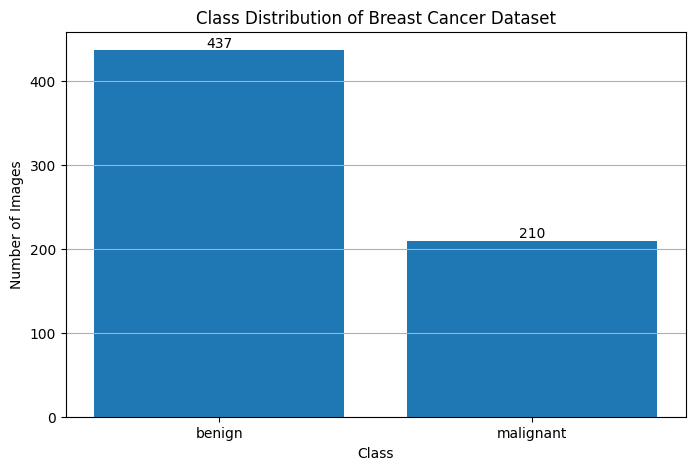

In [41]:
plt.figure(figsize=(8, 5))
bars = plt.bar(class_names, class_counts)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Breast Cancer Dataset")

# Show values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             int(yval), ha='center', va='bottom')

plt.grid(axis='y')
plt.show()



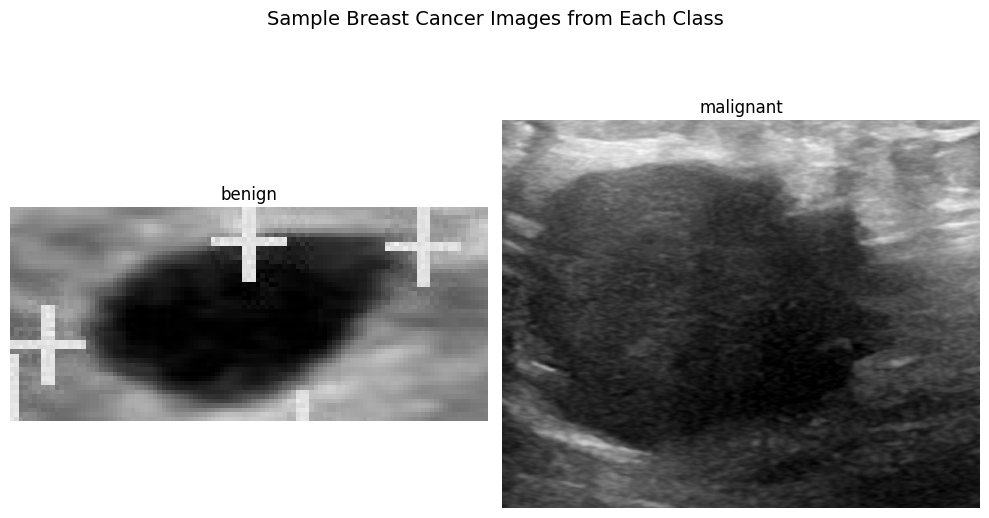

In [42]:
plt.figure(figsize=(10, 6))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dataset, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path).convert("RGB")

    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Sample Breast Cancer Images from Each Class", fontsize=14)
plt.tight_layout()
plt.show()



In [43]:
# Parameters
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 2
LEARNING_RATE = 3e-4




In [44]:
train_ds, validation_ds, test_ds, train_loader, validation_loader, test_loader = make_dataloaders(
    train_dataset,
    validation_dataset,
    test_dataset,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    backbone="inception_v3",
)



In [45]:
print("Classes:", train_ds.classes)
print("Class to index:", train_ds.class_to_idx)
print(f"Train samples: {len(train_ds)}")
print(f"Validation samples: {len(validation_ds)}")
print(f"Test samples: {len(test_ds)}")



Classes: ['benign', 'malignant']
Class to index: {'benign': 0, 'malignant': 1}
Train samples: 452
Validation samples: 97
Test samples: 98


In [46]:
class_names = train_ds.classes
NUM_CLASSES = len(class_names)



In [47]:
train_loader



In [48]:
test_loader



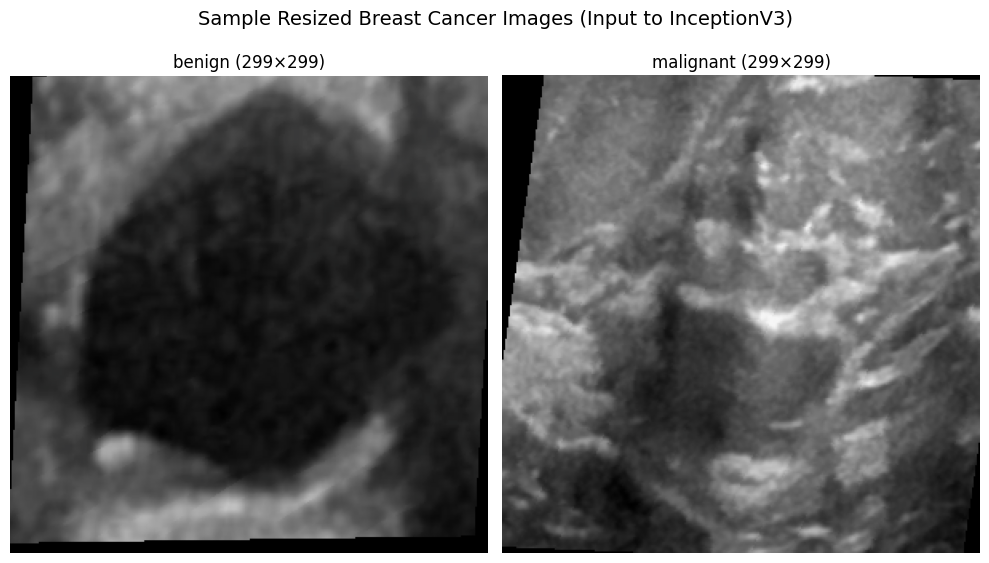

In [49]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))
shown = set()

for img, label in zip(images, labels):
    class_name = class_names[int(label)]

    if class_name not in shown:
        plt.subplot(1, 2, len(shown) + 1)
        plt.imshow(denormalize_image(img, backbone="inception_v3"))
        plt.title(class_name + " (299×299)")
        plt.axis("off")
        shown.add(class_name)

    if len(shown) == 2:
        break

plt.suptitle("Sample Resized Breast Cancer Images (Input to InceptionV3)", fontsize=14)
plt.tight_layout()
plt.show()



In [50]:
def build_inception(num_classes):
    weights = Inception_V3_Weights.IMAGENET1K_V1
    model = models.inception_v3(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze the top Inception blocks for better transfer learning
    for block in [model.Mixed_7a, model.Mixed_7b, model.Mixed_7c]:
        for param in block.parameters():
            param.requires_grad = True

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(512, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes),
    )

    if model.AuxLogits is not None:
        aux_in_features = model.AuxLogits.fc.in_features
        model.AuxLogits.fc = nn.Sequential(
            nn.Linear(aux_in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    for param in model.fc.parameters():
        param.requires_grad = True
    if model.AuxLogits is not None:
        for param in model.AuxLogits.parameters():
            param.requires_grad = True

    model.model_name = "InceptionV3"
    return model.to(device)




In [53]:
model = build_inception(NUM_CLASSES)
os.makedirs("inception", exist_ok=True)

criterion, classes, class_weights_arr, class_weights_tensor = make_weighted_criterion(
    train_ds.targets,
    device=device,
    label_smoothing=0.05,
)
optimizer = make_optimizer(
    model,
    base_lr=LEARNING_RATE,
    head_lr=LEARNING_RATE * 4,
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)
best_inception_path = "inception/inception_model.pth"

print(model)




Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [54]:
class_weight = {int(c): float(w) for c, w in zip(classes, class_weights_arr)}
print("Class weights:", class_weight)




Class weights: {0: 0.740983606557377, 1: 1.5374149659863945}


In [55]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    save_path=best_inception_path,
    scheduler=scheduler,
    patience=3,
)




Epoch 1/20:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1/20 | train_loss=0.7014 train_acc=0.5022 train_f1=0.4014 | val_loss=1.8640 val_acc=0.4124 val_f1=0.3406
Saved best model to inception/inception_model.pth


Epoch 2/20 | train_loss=0.4907 train_acc=0.8739 train_f1=0.8739 | val_loss=0.5041 val_acc=0.8351 val_f1=0.8364
Saved best model to inception/inception_model.pth


Epoch 3/20 | train_loss=0.3671 train_acc=0.9204 train_f1=0.9204 | val_loss=0.4981 val_acc=0.8351 val_f1=0.8250
Saved best model to inception/inception_model.pth


Epoch 4/20 | train_loss=0.3746 train_acc=0.8960 train_f1=0.8959 | val_loss=0.4519 val_acc=0.8454 val_f1=0.8481
Saved best model to inception/inception_model.pth


Epoch 5/20 | train_loss=0.3725 train_acc=0.9004 train_f1=0.9003 | val_loss=0.4423 val_acc=0.8969 val_f1=0.8977
Saved best model to inception/inception_model.pth


Epoch 6/20 | train_loss=0.3495 train_acc=0.8805 train_f1=0.8792 | val_loss=0.4719 val_acc=0.8763 val_f1=0.8781


Epoch 7/20 | train_loss=0.2868 train_acc=0.9469 train_f1=0.9468 | val_loss=0.5351 val_acc=0.8763 val_f1=0.8788


Epoch 8/20 | train_loss=0.3024 train_acc=0.9358 train_f1=0.9357 | val_loss=0.4748 val_acc=0.8866 val_f1=0.8861
Early stopping triggered.


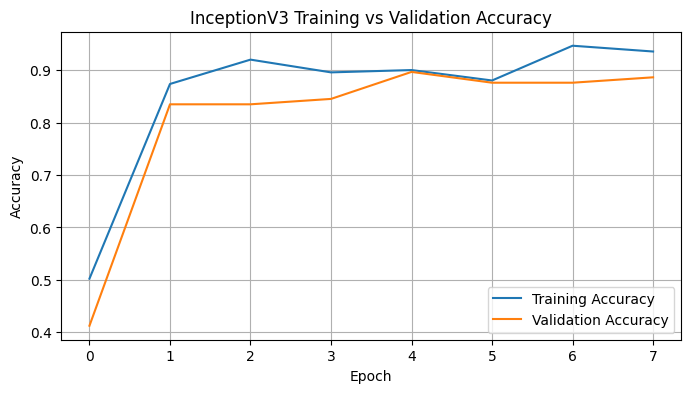

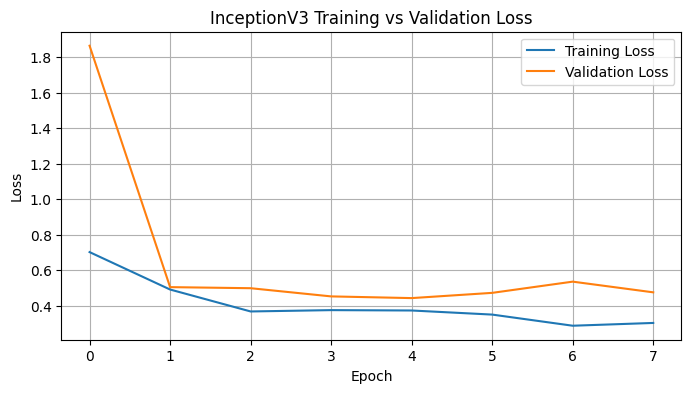

In [56]:
plot_training_curves(history, "InceptionV3")



In [57]:
val_metrics = evaluate_model(model, validation_loader, criterion, device)

results_summary["InceptionV3 Validation"] = {
    "Accuracy": val_metrics["accuracy"] * 100,
    "Precision": val_metrics["precision"] * 100,
    "Recall": val_metrics["recall"] * 100,
    "F1": val_metrics["f1"] * 100,
}

print(f"Loss: {val_metrics['loss']:.4f}")
print(f"Accuracy: {val_metrics['accuracy']*100:.2f}%")
print(f"Precision: {val_metrics['precision']*100:.2f}%")
print(f"Recall: {val_metrics['recall']*100:.2f}%")
print(f"F1 Score: {val_metrics['f1']*100:.2f}%")
print(f"Macro Precision: {val_metrics['macro_precision']*100:.2f}%")
print(f"Macro Recall: {val_metrics['macro_recall']*100:.2f}%")
print(f"Macro F1: {val_metrics['macro_f1']*100:.2f}%")

print("\nClassification report (validation):")
print(classification_report(
    val_metrics["y_true"],
    val_metrics["y_pred"],
    target_names=class_names,
    digits=4
))



Loss: 0.4423
Accuracy: 89.69%
Precision: 89.94%
Recall: 89.69%
F1 Score: 89.77%
Macro Precision: 87.78%
Macro Recall: 89.00%
Macro F1: 88.34%

Classification report (validation):
              precision    recall  f1-score   support

      benign     0.9375    0.9091    0.9231        66
   malignant     0.8182    0.8710    0.8438        31

    accuracy                         0.8969        97
   macro avg     0.8778    0.8900    0.8834        97
weighted avg     0.8994    0.8969    0.8977        97



In [81]:
model = build_inception(NUM_CLASSES)
model.load_state_dict(torch.load(best_inception_path, map_location=device))
model = model.to(device)

test_metrics = evaluate_model(model, test_loader, criterion, device)

results_summary["InceptionV3 Test"] = {
    "Accuracy": test_metrics["accuracy"] * 100,
    "Precision": test_metrics["precision"] * 100,
    "Recall": test_metrics["recall"] * 100,
    "F1": test_metrics["f1"] * 100,
}

print("\nTest (Unseen Data) Results")
print(f"Accuracy: {test_metrics['accuracy']*100:.2f}%")
print(f"Precision: {test_metrics['precision']*100:.2f}%")
print(f"Recall: {test_metrics['recall']*100:.2f}%")
print(f"F1 Score: {test_metrics['f1']*100:.2f}%")


Test (Unseen Data) Results
Accuracy: 81.63%
Precision: 83.58%
Recall: 81.63%
F1 Score: 82.06%


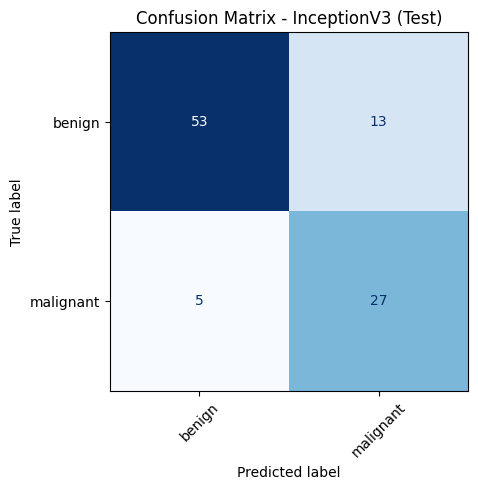

In [82]:
cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, values_format="d", colorbar=False)
plt.title("Confusion Matrix - InceptionV3 (Test)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




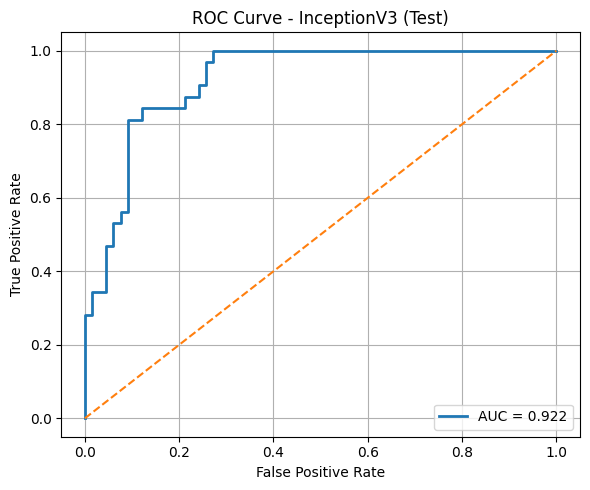

In [86]:

model.eval()

y_true = []
y_scores = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_scores.extend(probs[:, 1].cpu().numpy())  # class 1 = malignant

y_true = np.array(y_true)
y_scores = np.array(y_scores)

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - InceptionV3 (Test)")
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()